In [1]:
import numpy as np
import pandas as pd
import  seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('healthcare_dataset.csv')
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [4]:
df.shape

(55500, 15)

In [5]:
print(df.isnull().sum())
print(df.describe())

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64
                Age  Billing Amount   Room Number
count  55500.000000    55500.000000  55500.000000
mean      51.539459    25539.316097    301.134829
std       19.602454    14211.454431    115.243069
min       13.000000    -2008.492140    101.000000
25%       35.000000    13241.224652    202.000000
50%       52.000000    25538.069376    302.000000
75%       68.000000    37820.508436    401.000000
max       89.000000    52764.276736    500.000000


In [6]:
df.drop(columns=['Doctor'], inplace=True)

In [7]:
df.drop(columns=['Hospital'], inplace=True)

In [8]:
df.drop(columns=['Name'], inplace=True)

In [9]:
df.drop(columns=['Date of Admission'], inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 55500 non-null  int64  
 1   Gender              55500 non-null  object 
 2   Blood Type          55500 non-null  object 
 3   Medical Condition   55500 non-null  object 
 4   Insurance Provider  55500 non-null  object 
 5   Billing Amount      55500 non-null  float64
 6   Room Number         55500 non-null  int64  
 7   Admission Type      55500 non-null  object 
 8   Discharge Date      55500 non-null  object 
 9   Medication          55500 non-null  object 
 10  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 4.7+ MB


In [11]:
from sklearn.decomposition import PCA

In [12]:
# 1. Select relevant features and One-Hot Encode categories
# We drop 'Name', 'Doctor', 'Hospital', 'Date of Admission', etc.
features = df[['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Billing Amount', 'Admission Type', 'Test Results']]
features_encoded = pd.get_dummies(features, drop_first=True)

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
# Create the scaler object
scaler = StandardScaler()  # or MinMaxScaler() if you need values between 0 and 1

In [15]:
scaled_data = scaler.fit_transform(features_encoded)

In [16]:
# 3. Apply PCA
# Let's start by looking at 2 components for easy visualization
pca = PCA(n_components=2)
pca_results = pca.fit_transform(scaled_data)

In [17]:
pca_df = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'])
print(pca_df.head())

        PC1       PC2
0  0.058660 -2.158592
1 -0.051110  2.178839
2  2.135403  0.164884
3 -0.005429 -0.024024
4 -1.045994 -1.027339


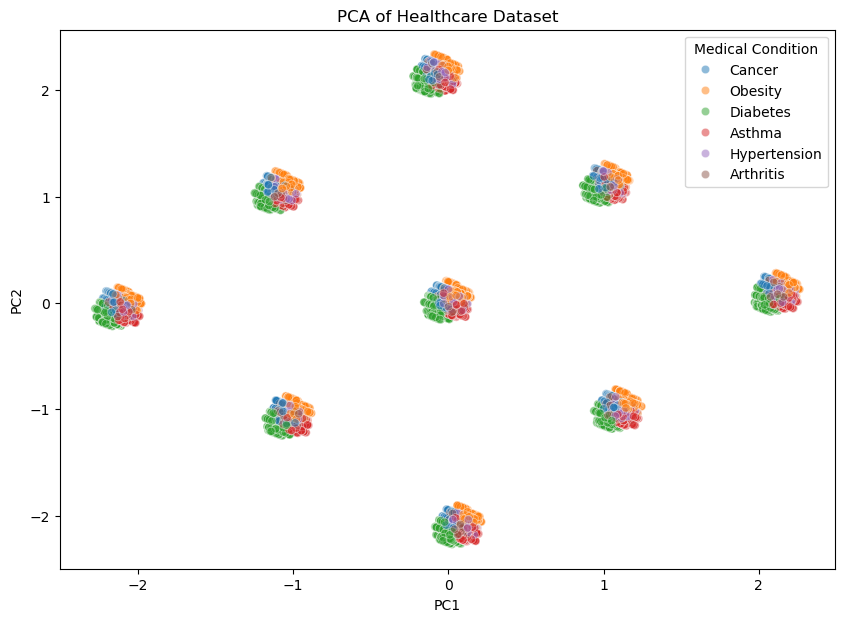

In [18]:
plt.figure(figsize=(10,7))
sns.scatterplot(x=pca_df['PC1'], y=pca_df['PC2'], hue=df['Medical Condition'], alpha=0.5)
plt.title('PCA of Healthcare Dataset')
plt.show()

In [19]:
# 1. Initialize PCA without a limit to see all components
pca_full = PCA()
pca_full.fit(scaled_data)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [20]:
# 2. Calculate cumulative variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

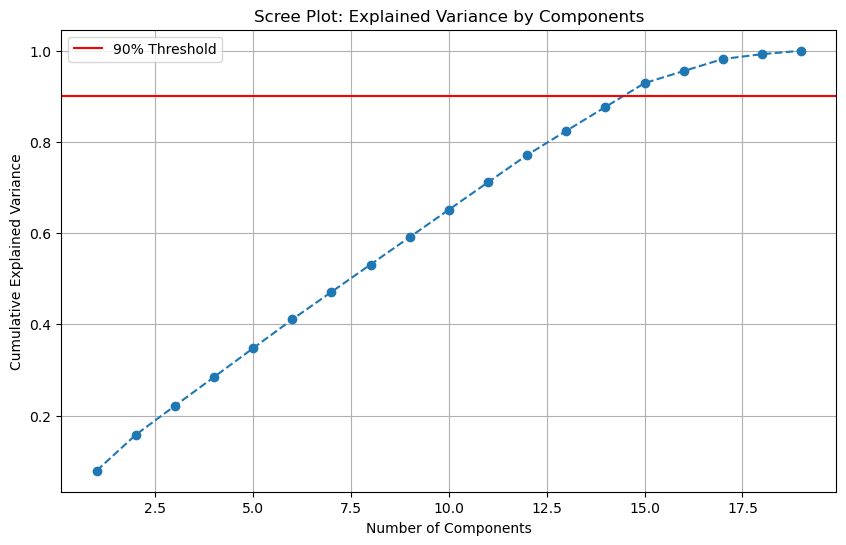

In [21]:
# 3. Plotting the Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-', label='90% Threshold')
plt.title('Scree Plot: Explained Variance by Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid()
plt.show()

In [22]:
# Applying the optimal number (e.g., 5)
final_pca = PCA(n_components=5)
final_data = final_pca.fit_transform(scaled_data)

# This 'final_data' is what you would use for a Machine Learning model!

In [23]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

##### 1. Prepare Data
##### We use 'Medical Condition' as the target (y) we want to separate.
##### We must exclude it from our features (X).

In [24]:
y = df['Medical Condition']
X = df.drop(columns=['Room Number', 'Discharge Date', 'Medical Condition'])

##### 2. Encode and Scale (Crucial for LDA as well)

In [25]:
X_encoded = pd.get_dummies(X, drop_first=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

##### 3. Apply LDA
##### LDA is limited to (number_of_classes - 1) components. 
##### Since we have 6 conditions, we can have up to 5 components. Let's use 2 for plotting.


In [26]:
lda = LinearDiscriminantAnalysis(n_components=2)
lda_results = lda.fit_transform(X_scaled, y)

 ##### 4. Create a DataFrame for results

In [27]:
lda_df = pd.DataFrame(data=lda_results, columns=['LD1', 'LD2'])
lda_df['Condition'] = y.values

In [28]:
print("Explained variance ratio (LDA):", lda.explained_variance_ratio_)

Explained variance ratio (LDA): [0.38591462 0.25197386]


##### 2. Visualization
##### To see if LDA was better than PCA at finding patterns related to sickness

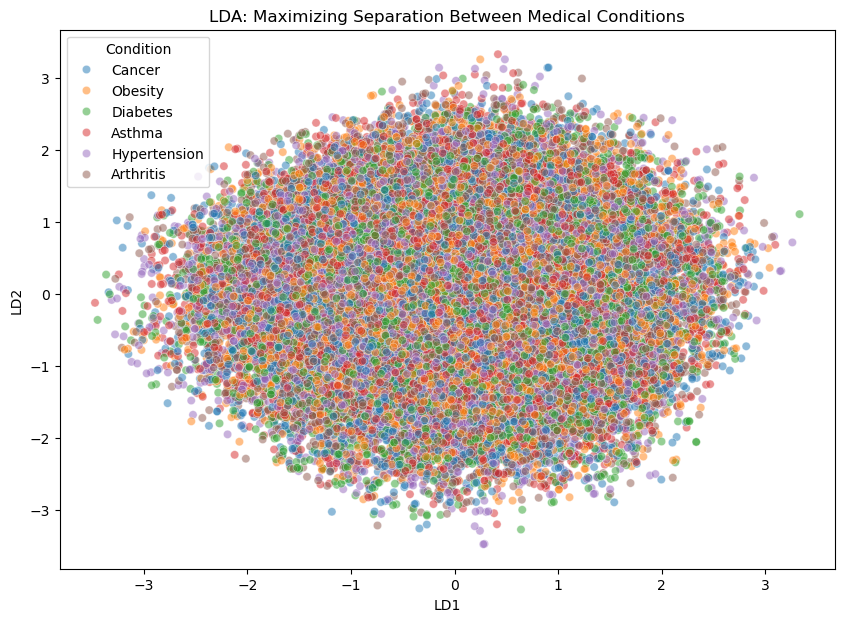

In [29]:
plt.figure(figsize=(10,7))
sns.scatterplot(x='LD1', y='LD2', hue='Condition', data=lda_df, alpha=0.5)
plt.title('LDA: Maximizing Separation Between Medical Conditions')
plt.show()